https://colab.research.google.com/drive/1uVoDnn0xwbKNM0mgmd3y1raEO8yiWH42?usp=sharing


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42
DATA_DIR = Path("data/interim")

# -----------------------------
# load data
# -----------------------------
m_train = pd.read_csv(DATA_DIR / "m_matchups_train_2014_2024.csv")
m_valid = pd.read_csv(DATA_DIR / "m_matchups_valid_2025.csv")
m_full  = pd.read_csv(DATA_DIR / "m_matchups_full_train_2014_2025.csv")
m_pred  = pd.read_csv(DATA_DIR / "m_matchups_stage2_2026.csv")

w_train = pd.read_csv(DATA_DIR / "w_matchups_train_2014_2024.csv")
w_valid = pd.read_csv(DATA_DIR / "w_matchups_valid_2025.csv")
w_full  = pd.read_csv(DATA_DIR / "w_matchups_full_train_2014_2025.csv")
w_pred  = pd.read_csv(DATA_DIR / "w_matchups_stage2_2026.csv")

print("M train:", m_train.shape, "M valid:", m_valid.shape, "M pred:", m_pred.shape)
print("W train:", w_train.shape, "W valid:", w_valid.shape, "W pred:", w_pred.shape)

M train: (669, 270) M valid: (67, 270) M pred: (66430, 268)
W train: (642, 237) W valid: (67, 237) W pred: (65703, 235)


In [3]:
def get_feature_columns(train_df, valid_df, pred_df):
    common_cols = sorted(set(train_df.columns) & set(valid_df.columns) & set(pred_df.columns))

    # tylko numeryczne Diff_* i Same_*
    feat_cols = []
    for c in common_cols:
        if c in ["Target", "ID", "Sex", "Season", "DayNum", "NumOT", "TeamIDLow", "TeamIDHigh"]:
            continue
        if c.startswith("Diff_") or c.startswith("Same_"):
            if pd.api.types.is_numeric_dtype(train_df[c]):
                feat_cols.append(c)

    # wywalamy stałe
    feat_cols = [c for c in feat_cols if train_df[c].nunique(dropna=True) > 1]
    return feat_cols

def clip_probs(p, eps=1e-6):
    return np.clip(p, eps, 1 - eps)

def score_predictions(y_true, p):
    p = clip_probs(p)
    return {
        "brier": brier_score_loss(y_true, p),
        "logloss": log_loss(y_true, p),
    }

m_features = get_feature_columns(m_train, m_valid, m_pred)
w_features = get_feature_columns(w_train, w_valid, w_pred)

print("M feature count:", len(m_features))
print("W feature count:", len(w_features))
print("\nTop M features:", m_features[:15])
print("\nTop W features:", w_features[:15])

M feature count: 85
W feature count: 75

Top M features: ['Diff_AstRateAllowedAvg', 'Diff_AstRateAvg', 'Diff_AvgAst', 'Diff_AvgBlk', 'Diff_AvgDR', 'Diff_AvgFGA', 'Diff_AvgFGA3', 'Diff_AvgFGM', 'Diff_AvgFGM3', 'Diff_AvgFTA', 'Diff_AvgFTM', 'Diff_AvgOR', 'Diff_AvgPF', 'Diff_AvgStl', 'Diff_AvgTO']

Top W features: ['Diff_AstRateAllowedAvg', 'Diff_AstRateAvg', 'Diff_AvgAst', 'Diff_AvgBlk', 'Diff_AvgDR', 'Diff_AvgFGA', 'Diff_AvgFGA3', 'Diff_AvgFGM', 'Diff_AvgFGM3', 'Diff_AvgFTA', 'Diff_AvgFTM', 'Diff_AvgOR', 'Diff_AvgPF', 'Diff_AvgStl', 'Diff_AvgTO']


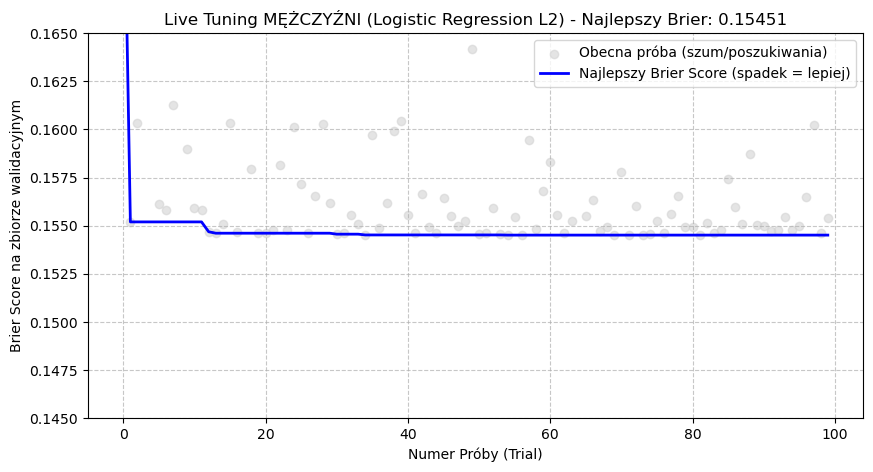


--- ZAKOŃCZONO TUNING DLA MĘŻCZYZN ---
Najlepsze parametry: {'C': 0.9684948809260349, 'tol': 0.0029099443715633853}
Najlepszy Brier Score: 0.15451


In [4]:
!pip install optuna -q

import optuna
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# Zmienne do śledzenia postępów na wykresie
m_best_scores = []
m_current_scores = []

def plot_live_m(study, trial):
    """Callback do rysowania wykresu na żywo dla mężczyzn"""
    m_best_scores.append(study.best_value)
    m_current_scores.append(trial.value)
    
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    
    # Wykres wszystkich prób i najlepszego wyniku
    plt.scatter(range(len(m_current_scores)), m_current_scores, color='lightgray', label='Obecna próba (szum/poszukiwania)', alpha=0.6)
    plt.plot(m_best_scores, color='blue', linewidth=2, label='Najlepszy Brier Score (spadek = lepiej)')
    
    plt.ylim(0.145, 0.165) # Zawężamy oś Y dla lepszej czytelności (dostosuj jeśli wyjdzie poza skalę)
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score na zbiorze walidacyjnym')
    plt.title(f'Live Tuning MĘŻCZYŹNI (Logistic Regression L2) - Najlepszy Brier: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_m(trial):
    # Optuna sama dobiera hiperparametry z tych przedziałów
    C_val = trial.suggest_float('C', 1e-4, 10.0, log=True)
    tol_val = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            C=C_val,
            tol=tol_val,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        ))
    ])
    
    # Trening na 2014-2024
    model.fit(m_train[m_features], m_train["Target"])
    # Ewaluacja na 2025
    p_valid = model.predict_proba(m_valid[m_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)
    
    return brier_score_loss(m_valid["Target"], p_valid)

print("Rozpoczynam mordercze poszukiwania parametrów dla Mężczyzn...")
study_m = optuna.create_study(direction='minimize')
# Odpalamy 100 prób z live plotem
study_m.optimize(objective_m, n_trials=100, callbacks=[plot_live_m])

print("\n--- ZAKOŃCZONO TUNING DLA MĘŻCZYZN ---")
print("Najlepsze parametry:", study_m.best_params)
print(f"Najlepszy Brier Score: {study_m.best_value:.5f}")

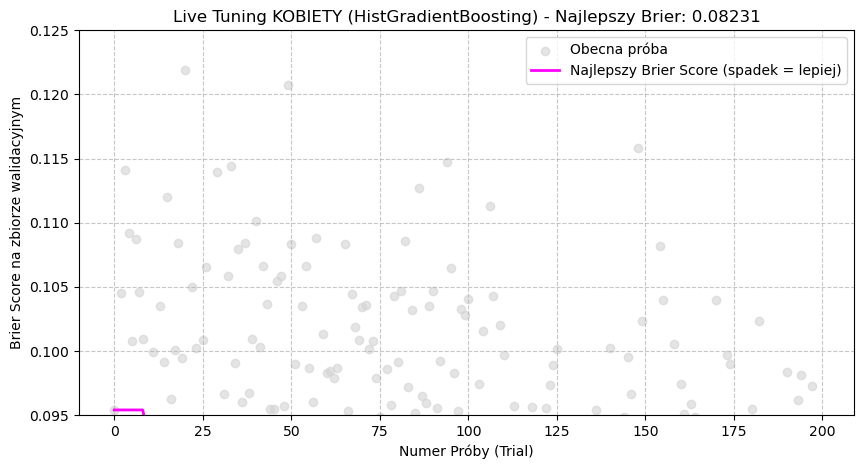


--- ZAKOŃCZONO TUNING DLA KOBIET ---
Najlepsze parametry: {'learning_rate': 0.012744487879133853, 'max_iter': 594, 'max_depth': 6, 'min_samples_leaf': 8, 'l2_regularization': 3.8674548995754274, 'max_bins': 162}
Najlepszy Brier Score: 0.08231


In [5]:
# Zmienne do śledzenia postępów na wykresie
w_best_scores = []
w_current_scores = []

def plot_live_w(study, trial):
    """Callback do rysowania wykresu na żywo dla kobiet"""
    w_best_scores.append(study.best_value)
    w_current_scores.append(trial.value)
    
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(w_current_scores)), w_current_scores, color='lightgray', label='Obecna próba', alpha=0.6)
    plt.plot(w_best_scores, color='magenta', linewidth=2, label='Najlepszy Brier Score (spadek = lepiej)')
    
    plt.ylim(0.095, 0.125) # Dostosowane do Twojego wspaniałego wyniku ~0.105
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score na zbiorze walidacyjnym')
    plt.title(f'Live Tuning KOBIETY (HistGradientBoosting) - Najlepszy Brier: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_w(trial):
    # Gigantyczna siatka dla algorytmu gradientowego
    lr = trial.suggest_float('learning_rate', 0.005, 0.1, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 800)
    max_depth = trial.suggest_int('max_depth', 2, 7)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50)
    l2_reg = trial.suggest_float('l2_regularization', 0.0, 5.0)
    max_bins = trial.suggest_int('max_bins', 64, 255)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=lr,
            max_iter=max_iter,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_reg,
            max_bins=max_bins,
            random_state=42
        ))
    ])
    
    model.fit(w_train[w_features], w_train["Target"])
    p_valid = model.predict_proba(w_valid[w_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)
    
    return brier_score_loss(w_valid["Target"], p_valid)

print("Rozpoczynam mordercze poszukiwania parametrów dla Kobiet...")
study_w = optuna.create_study(direction='minimize')
# 200 prób - niech komputer zapracuje na swój prąd
study_w.optimize(objective_w, n_trials=200, callbacks=[plot_live_w])

print("\n--- ZAKOŃCZONO TUNING DLA KOBIET ---")
print("Najlepsze parametry:", study_w.best_params)
print(f"Najlepszy Brier Score: {study_w.best_value:.5f}")

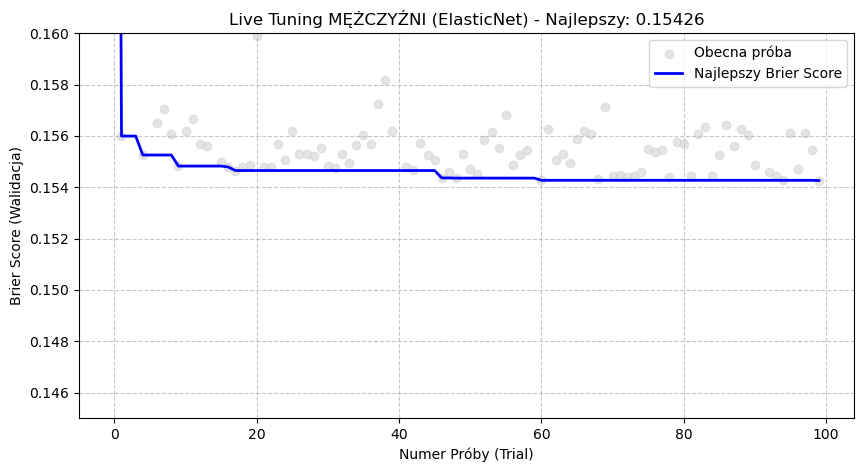


--- ZAKOŃCZONO TUNING ELASTICNET (MĘŻCZYŹNI) ---
Najlepsze parametry: {'C': 0.2785270645555312, 'l1_ratio': 0.8047896971987528}
Najlepszy Brier Score: 0.15426


In [6]:
# Zmienne do śledzenia postępów na wykresie
m_elastic_best_scores = []
m_elastic_current_scores = []

def plot_live_m_elastic(study, trial):
    """Callback do rysowania wykresu na żywo dla mężczyzn (ElasticNet)"""
    m_elastic_best_scores.append(study.best_value)
    m_elastic_current_scores.append(trial.value)
    
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(m_elastic_current_scores)), m_elastic_current_scores, color='lightgray', label='Obecna próba', alpha=0.6)
    plt.plot(m_elastic_best_scores, color='blue', linewidth=2, label='Najlepszy Brier Score')
    
    plt.ylim(0.145, 0.160) 
    plt.xlabel('Numer Próby (Trial)')
    plt.ylabel('Brier Score (Walidacja)')
    plt.title(f'Live Tuning MĘŻCZYŹNI (ElasticNet) - Najlepszy: {study.best_value:.5f}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def objective_m_elastic(trial):
    # Szeroki zakres dla C (siła regularyzacji ogółem)
    C_val = trial.suggest_float('C', 1e-3, 10.0, log=True)
    # l1_ratio: 0 to czyste L2, 1 to czyste L1. Szukamy złotego środka.
    l1_ratio_val = trial.suggest_float('l1_ratio', 0.01, 0.99)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            C=C_val,
            l1_ratio=l1_ratio_val,
            solver="saga", # SAGA jest wymagany dla ElasticNet
            max_iter=5000,
            random_state=42
        ))
    ])
    
    model.fit(m_train[m_features], m_train["Target"])
    p_valid = model.predict_proba(m_valid[m_features])[:, 1]
    p_valid = np.clip(p_valid, 1e-6, 1 - 1e-6)
    
    return brier_score_loss(m_valid["Target"], p_valid)

print("Rozpoczynam polowanie na zredukowane L2 (ElasticNet) dla mężczyzn...")
study_m_elastic = optuna.create_study(direction='minimize')
study_m_elastic.optimize(objective_m_elastic, n_trials=100, callbacks=[plot_live_m_elastic])

print("\n--- ZAKOŃCZONO TUNING ELASTICNET (MĘŻCZYŹNI) ---")
print("Najlepsze parametry:", study_m_elastic.best_params)
print(f"Najlepszy Brier Score: {study_m_elastic.best_value:.5f}")

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

print("Tworzenie ostatecznych, zoptymalizowanych modeli...")

# MĘŻCZYŹNI - ElasticNet (Balans między L1 i L2)
final_m_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        C=0.2785270645555312,
        l1_ratio=0.8047896971987528,
        solver="saga",
        max_iter=5000,
        random_state=42
    ))
])

# KOBIETY - HistGradientBoosting (Potężny kombajn na drzewach decyzyjnych)
final_w_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.012744487879133853,
        max_iter=594,
        max_depth=6,
        min_samples_leaf=8,
        l2_regularization=3.8674548995754274,
        max_bins=162,
        random_state=42
    ))
])

def predict_final(full_df, pred_df, feature_cols, model_pipeline):
    X_full = full_df[feature_cols].copy()
    y_full = full_df["Target"].astype(int).copy()
    X_pred = pred_df[feature_cols].copy()
    
    print(f"Trenowanie na {len(X_full)} próbkach...")
    model_pipeline.fit(X_full, y_full)
    
    print(f"Generowanie predykcji dla {len(X_pred)} potencjalnych meczów...")
    p_pred = model_pipeline.predict_proba(X_pred)[:, 1]
    
    # Minimalny clipping - zostawiamy margines na niespodzianki
    p_pred = np.clip(p_pred, 1e-6, 1 - 1e-6) 
    
    return pd.DataFrame({
        "ID": pred_df["ID"].values,
        "Pred": p_pred
    })

print("\n--- Przetwarzanie turnieju Mężczyzn ---")
m_submission = predict_final(m_full, m_pred, m_features, final_m_model)

print("\n--- Przetwarzanie turnieju Kobiet ---")
w_submission = predict_final(w_full, w_pred, w_features, final_w_model)

print("\nSkładanie ostatecznego pliku CSV...")
final_submission = pd.concat([m_submission, w_submission], ignore_index=True)
final_submission = final_submission.sort_values("ID").reset_index(drop=True)

# Zapis do pliku
DATA_DIR = Path("data/interim") # Zmień na swój folder na Drive, jeśli potrzeba
out_path = DATA_DIR / "final_submission_optuna_tuned_2026.csv"
final_submission.to_csv(out_path, index=False)

print(f"\nZAKOŃCZONO! Zapisano plik: {out_path}")
print(f"Kształt submisji: {final_submission.shape} (Zgodnie z zasadami Kaggle 2026)")
display(final_submission.head())

Tworzenie ostatecznych, zoptymalizowanych modeli...

--- Przetwarzanie turnieju Mężczyzn ---
Trenowanie na 736 próbkach...
Generowanie predykcji dla 66430 potencjalnych meczów...

--- Przetwarzanie turnieju Kobiet ---
Trenowanie na 709 próbkach...
Generowanie predykcji dla 65703 potencjalnych meczów...

Składanie ostatecznego pliku CSV...

ZAKOŃCZONO! Zapisano plik: data\interim\final_submission_optuna_tuned_2026.csv
Kształt submisji: (132133, 2) (Zgodnie z zasadami Kaggle 2026)


,ID,Pred
0,2026_1101_1102,0.549396
1,2026_1101_1103,0.175545
2,2026_1101_1104,0.101244
3,2026_1101_1105,0.781008
4,2026_1101_1106,0.659854
